<a href="https://colab.research.google.com/github/Mystic2122/CSC665_AI_Team10/blob/Nick/model_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


Found 150 Pokémon categories:

Showing 5 images from 'Dragonite'


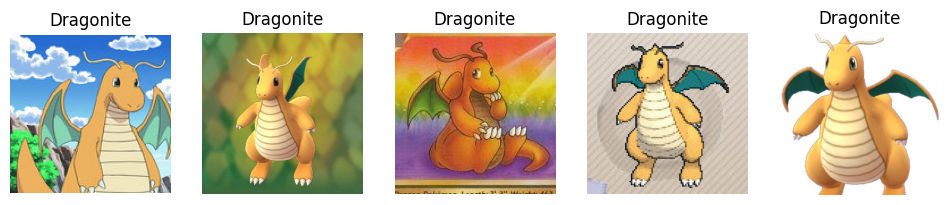

In [7]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import kagglehub

path = kagglehub.dataset_download("lantian773030/pokemonclassification")

inner_path = os.path.join(path, "PokemonData")

pokemon_folders = os.listdir(inner_path)
print(f"Found {len(pokemon_folders)} Pokémon categories:")

pokemon = "Dragonite"
pokemon_path = os.path.join(inner_path, pokemon)

images = [f for f in os.listdir(pokemon_path)
          if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:5]

print(f"\nShowing {len(images)} images from '{pokemon}'")

plt.figure(figsize=(12, 4))
for i, img_name in enumerate(images):
    img_path = os.path.join(pokemon_path, img_name)
    img = mpimg.imread(img_path)
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(pokemon)
plt.show()

In [8]:
# Load models
import json
import tensorflow as tf

cnn_model_path = "/content/drive/MyDrive/pokemon_cnn.keras"
mobilenet_model_path = "/content/drive/MyDrive/pokemon_mobile_net.keras"
dropout_model_path = "/content/drive/MyDrive/pokemon_cnn_dropout.keras"
final_model_path = "/content/drive/MyDrive/pokemon_final_model.keras"

cnn_model = tf.keras.models.load_model(cnn_model_path)
mobilenet_model = tf.keras.models.load_model(mobilenet_model_path)
dropout_model = tf.keras.models.load_model(dropout_model_path)
final_model = tf.keras.models.load_model(final_model_path)

print("Models loaded successfully!")

# Load Labels
labels_path = "/content/drive/MyDrive/pokemon_labels.json"
with open(labels_path, "r") as f:
    labels = json.load(f)
print("Loaded labels")

Models loaded successfully!
Loaded labels


Saving snorlax.jpg to snorlax (2).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


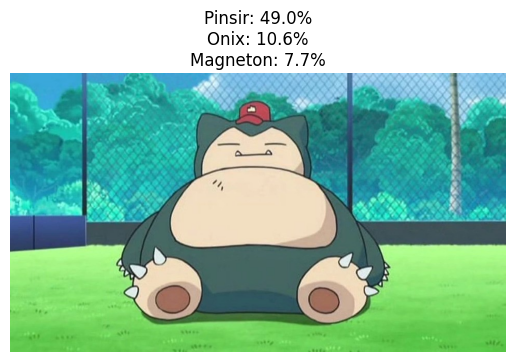

Pinsir: 49.0%
Onix: 10.6%
Magneton: 7.7%


In [ ]:
# TOP 3 PREDICTIONS USING CNN MODEL
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# ---- UPLOAD IMAGE ----
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ---- PREPROCESS ----
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, 0) / 255.0

# ---- PREDICT ----
preds = cnn_model.predict(img_array)[0]   # <--- OR cnn_model.predict(img_array)[0]

# ---- GET TOP 3 ----
top3_idx = preds.argsort()[-3:][::-1]   # last 3, descending order

top3_labels = [(labels[i], preds[i] * 100) for i in top3_idx]

# ---- DISPLAY RESULT ----
plt.imshow(plt.imread(img_path))
plt.axis("off")

title = "\n".join([f"{name}: {conf:.1f}%" for name, conf in top3_labels])
plt.title(title)
plt.show()

# Also print them cleanly
for name, conf in top3_labels:
    print(f"{name}: {conf:.1f}%")

Saving snorlax.jpg to snorlax (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step


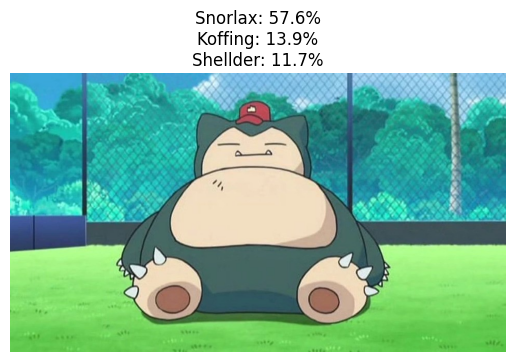

Snorlax: 57.6%
Koffing: 13.9%
Shellder: 11.7%


In [ ]:
# TOP 3 PREDICTIONS USING MOBILE NET MODEL
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# ---- UPLOAD IMAGE ----
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ---- PREPROCESS ----
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, 0) / 255.0

# ---- PREDICT ----
preds = mobilenet_model.predict(img_array)[0]   # <--- OR cnn_model.predict(img_array)[0]

# ---- GET TOP 3 ----
top3_idx = preds.argsort()[-3:][::-1]   # last 3, descending order

top3_labels = [(labels[i], preds[i] * 100) for i in top3_idx]

# ---- DISPLAY RESULT ----
plt.imshow(plt.imread(img_path))
plt.axis("off")

title = "\n".join([f"{name}: {conf:.1f}%" for name, conf in top3_labels])
plt.title(title)
plt.show()

# Also print them cleanly
for name, conf in top3_labels:
    print(f"{name}: {conf:.1f}%")

Saving snorlax.jpg to snorlax (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


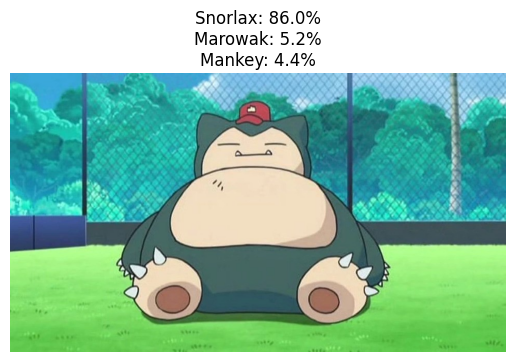

Snorlax: 86.0%
Marowak: 5.2%
Mankey: 4.4%


In [7]:
# Final Model

# TOP 3 PREDICTIONS USING FINAL DROPOUT MODEL WITH EARLY STOPPING
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# ---- UPLOAD IMAGE ----
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ---- PREPROCESS ----
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, 0) / 255.0

# ---- PREDICT ----
preds = final_model.predict(img_array)[0]

# ---- GET TOP 3 ----
top3_idx = preds.argsort()[-3:][::-1]

top3_labels = [(labels[i], preds[i] * 100) for i in top3_idx]

# ---- DISPLAY RESULT ----
plt.imshow(plt.imread(img_path))
plt.axis("off")

title = "\n".join([f"{name}: {conf:.1f}%" for name, conf in top3_labels])
plt.title(title)
plt.show()

# Also print them cleanly
for name, conf in top3_labels:
    print(f"{name}: {conf:.1f}%")

In [12]:
# Basic CNN Evaluation

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import kagglehub
import os

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Load dataset again
path = kagglehub.dataset_download("lantian773030/pokemonclassification")
inner_path = os.path.join(path, "PokemonData")

# Image generator
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Training data
train_data = datagen.flow_from_directory(
    inner_path,
    target_size=(128, 128),
    batch_size=32,
    subset="training",
    class_mode="categorical",
    shuffle=False   # must be False when evaluating!
)

# Validation data
val_data = datagen.flow_from_directory(
    inner_path,
    target_size=(128, 128),
    batch_size=32,
    subset="validation",
    class_mode="categorical",
    shuffle=False
)

# Load saved model
cnn_model = tf.keras.models.load_model("/content/drive/MyDrive/pokemon_cnn.keras")

# Evaluate training accuracy
train_loss, train_acc = cnn_model.evaluate(train_data)
print(f"Training Accuracy: {train_acc * 100:.2f}%  |  Training Loss: {train_loss:.4f}")

# Evaluate validation accuracy
val_loss, val_acc = cnn_model.evaluate(val_data)
print(f"Validation Accuracy: {val_acc * 100:.2f}%  |  Validation Loss: {val_loss:.4f}")



Mounted at /content/drive
Using Colab cache for faster access to the 'pokemonclassification' dataset.
Found 5511 images belonging to 150 classes.
Found 1309 images belonging to 150 classes.
173/173 ━━━━━━━━━━━━━━━━━━━━ 99s 567ms/step - accuracy: 0.9417 - loss: 0.2610
Training Accuracy: 94.19%  |  Training Loss: 0.2407
41/41 ━━━━━━━━━━━━━━━━━━━━ 23s 558ms/step - accuracy: 0.4611 - loss: 2.9260
Validation Accuracy: 46.68%  |  Validation Loss: 2.8885


In [13]:
# Dropout Model Evaluation

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import kagglehub
import os

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Load dataset again
path = kagglehub.dataset_download("lantian773030/pokemonclassification")
inner_path = os.path.join(path, "PokemonData")

# Image generator
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Training data
train_data = datagen.flow_from_directory(
    inner_path,
    target_size=(128, 128),
    batch_size=32,
    subset="training",
    class_mode="categorical",
    shuffle=False
)

# Validation data
val_data = datagen.flow_from_directory(
    inner_path,
    target_size=(128, 128),
    batch_size=32,
    subset="validation",
    class_mode="categorical",
    shuffle=False
)

# Load saved model
cnn_model = tf.keras.models.load_model("/content/drive/MyDrive/pokemon_final_model.keras")

# Evaluate training accuracy
train_loss, train_acc = cnn_model.evaluate(train_data)
print(f"Training Accuracy: {train_acc * 100:.2f}%  |  Training Loss: {train_loss:.4f}")

# Evaluate validation accuracy
val_loss, val_acc = cnn_model.evaluate(val_data)
print(f"Validation Accuracy: {val_acc * 100:.2f}%  |  Validation Loss: {val_loss:.4f}")



Mounted at /content/drive
Using Colab cache for faster access to the 'pokemonclassification' dataset.
Found 5511 images belonging to 150 classes.
Found 1309 images belonging to 150 classes.
173/173 ━━━━━━━━━━━━━━━━━━━━ 92s 529ms/step - accuracy: 0.9642 - loss: 0.1981
Training Accuracy: 96.19%  |  Training Loss: 0.1982
41/41 ━━━━━━━━━━━━━━━━━━━━ 23s 549ms/step - accuracy: 0.5242 - loss: 1.9521
Validation Accuracy: 53.55%  |  Validation Loss: 1.9595


In [1]:
# MobileNet Model Evaluation

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import kagglehub
import os

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Load dataset again
path = kagglehub.dataset_download("lantian773030/pokemonclassification")
inner_path = os.path.join(path, "PokemonData")

# Image generator
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Training data
train_data = datagen.flow_from_directory(
    inner_path,
    target_size=(128, 128),
    batch_size=32,
    subset="training",
    class_mode="categorical",
    shuffle=False   # must be False when evaluating!
)

# Validation data
val_data = datagen.flow_from_directory(
    inner_path,
    target_size=(128, 128),
    batch_size=32,
    subset="validation",
    class_mode="categorical",
    shuffle=False
)

# Load saved model
cnn_model = tf.keras.models.load_model("/content/drive/MyDrive/pokemon_mobile_net.keras")

# Evaluate training accuracy
train_loss, train_acc = cnn_model.evaluate(train_data)
print(f"Training Accuracy: {train_acc * 100:.2f}%  |  Training Loss: {train_loss:.4f}")

# Evaluate validation accuracy
val_loss, val_acc = cnn_model.evaluate(val_data)
print(f"Validation Accuracy: {val_acc * 100:.2f}%  |  Validation Loss: {val_loss:.4f}")






Mounted at /content/drive


100%|██████████| 417M/417M [00:19<00:00, 22.1MB/s]

Extracting files...


Found 5511 images belonging to 150 classes.
Found 1309 images belonging to 150 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


173/173 ━━━━━━━━━━━━━━━━━━━━ 50s 179ms/step - accuracy: 0.9825 - loss: 0.1614
Training Accuracy: 98.66%  |  Training Loss: 0.1435
41/41 ━━━━━━━━━━━━━━━━━━━━ 18s 456ms/step - accuracy: 0.7040 - loss: 1.1839
Validation Accuracy: 70.59%  |  Validation Loss: 1.2347
